# 🏠 House Price Prediction using Simple Linear Regression

This notebook demonstrates the implementation of **Simple Linear Regression** to predict house prices based on a single independent variable (Area).

The goal is to understand:
- The mathematical foundation of linear regression
- How the regression line is computed
- How predictions are made
- How to evaluate regression performance

## 📌 Problem Statement

Given the area of a house, predict its price using a linear regression model.

We assume a linear relationship of the form:

\[
Price = m \times Area + b
\]

Where:
- **m** → Slope (rate of change of price with respect to area)
- **b** → Intercept (base price when area = 0)

## 📚 Importing Required Libraries

We use the following libraries:

- **NumPy** → Numerical operations
- **Pandas** → Data handling
- **Matplotlib** → Visualization
- **Scikit-learn** → Machine Learning model implementation

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn import linear_model 

## 📂 Loading and Exploring the Dataset

In this step:
- Load the dataset
- Check basic structure
- Understand feature and target variables

In [2]:
df = pd.read_csv("homeprices (1).csv")
df.head()

,area,bedrooms,age,price
0,2600,3.0,20,550000
1,3000,4.0,15,565000
2,3200,NaN,18,610000
3,3600,3.0,30,595000
4,4000,5.0,8,760000


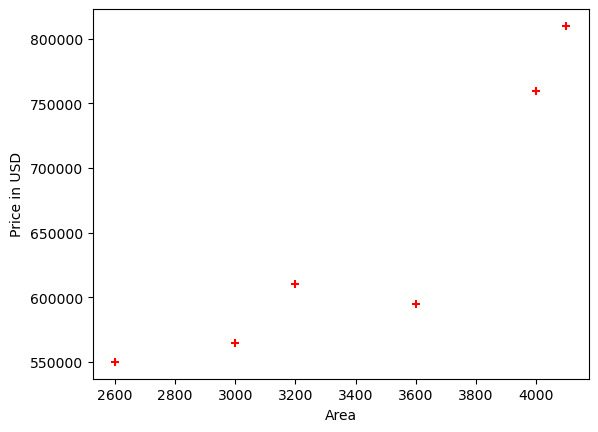

In [3]:
plt.scatter(df['area'],df['price'],marker = '+',color = 'red')
plt.xlabel("Area")
plt.ylabel("Price in USD")
plt.show()


## 🤖 Training the Linear Regression Model

We use Scikit-learn's LinearRegression model to:

1. Fit the regression line
2. Learn the slope (m)
3. Learn the intercept (b)

The model finds the best-fit line by minimizing the **Mean Squared Error (MSE)**.

In [4]:
reg = linear_model.LinearRegression()
reg.fit(df[['area']],df['price'])

LinearRegression()

In [5]:
reg.predict([[3300]])

C:\Users\HEMANTH KUMAR K\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([628813.88621022])

In [6]:
reg.coef_

array([167.30954677])

In [7]:
reg.predict([[1000]])

C:\Users\HEMANTH KUMAR K\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([244001.92864031])

## 🧮 Interpreting the Model

After training, we obtain:

- Slope (m)
- Intercept (b)

The final prediction equation becomes:

\[
Price = m \times Area + b
\]

Interpretation:
- The slope tells us how much the price increases for every 1 unit increase in area.
- The intercept represents the base price.

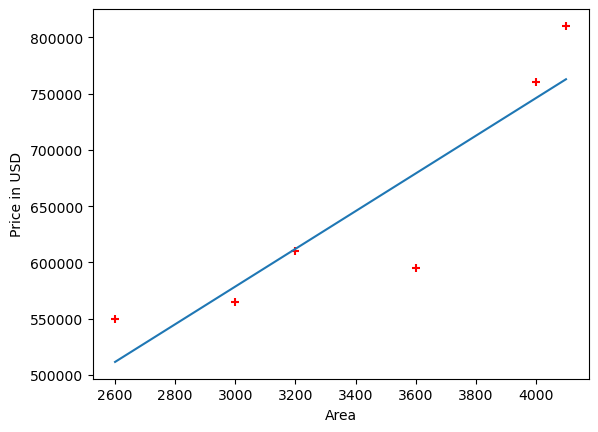

In [8]:
plt.scatter(df[['area']],df.price,marker = '+',color = 'red')
plt.xlabel("Area")
plt.ylabel("Price in USD")

plt.plot(df[['area']],reg.predict(df[['area']]))
plt.show()

In [9]:
y = df[['price']]
y_pred = reg.predict(df[['area']])
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
mse = mean_squared_error(y, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y, y_pred)
r2 = r2_score(y, y_pred)
print("📊 Model Evaluation Metrics")
print("----------------------------")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R² Score: {r2:.4f}")

📊 Model Evaluation Metrics
----------------------------
Mean Absolute Error (MAE): 33236.90
Mean Squared Error (MSE): 1858831565.41
Root Mean Squared Error (RMSE): 43114.17
R² Score: 0.8127


In [10]:
df2 = pd.read_csv("canada_per_capita_income.csv")
df2.head()
df2.info()
df2['price'] = df2['per capita income (US$)']


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47 entries, 0 to 46
Data columns (total 2 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   year                     47 non-null     int64  
 1   per capita income (US$)  47 non-null     float64
dtypes: float64(1), int64(1)
memory usage: 884.0 bytes


In [11]:
df2.head()
df2.drop("per capita income (US$)",axis = 1,inplace = True)	

In [12]:
df2.head()

,year,price
0,1970,3399.299037
1,1971,3768.297935
2,1972,4251.175484
3,1973,4804.463248
4,1974,5576.514583


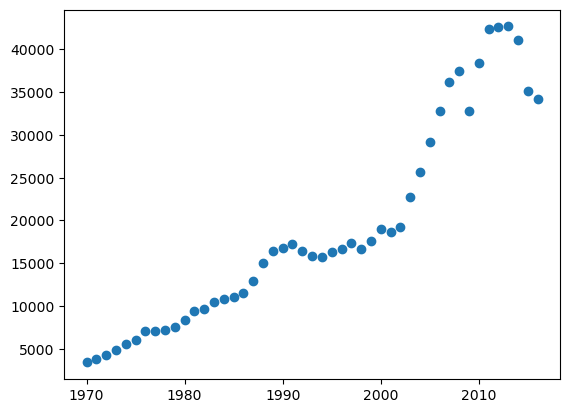

In [13]:
plt.scatter(df2.year,df2.price)
plt.show()

In [14]:
reg2 = linear_model.LinearRegression()
reg2.fit(df2[['year']],df2.price)

LinearRegression()

In [15]:
reg2.predict([[2024]])

C:\Users\HEMANTH KUMAR K\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([44602.55439531])

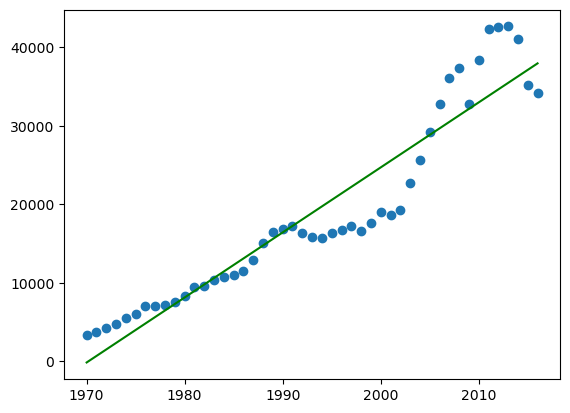

In [16]:
plt.scatter(df2.year,df2.price)
plt.plot(df2[['year']],reg2.predict(df2[['year']]),color = 'green')
plt.show()

In [17]:
df2['predicted'] = reg2.predict(df2[['year']])
df2.head(10)

,year,price,predicted
0,1970,3399.299037,-134.559667
1,1971,3768.297935,693.905409
2,1972,4251.175484,1522.370484
3,1973,4804.463248,2350.835559
4,1974,5576.514583,3179.300634
5,1975,5998.144346,4007.765709
6,1976,7062.131392,4836.230785
7,1977,7100.126170,5664.695860
8,1978,7247.967035,6493.160935
9,1979,7602.912681,7321.626010


In [18]:
from sklearn.metrics import mean_squared_error
mse = mean_squared_error(df2.price, df2.predicted)
print("Accuracy: "+str(mse))

Accuracy: 15462739.061504772


In [19]:
mse_percentage = (mse / (np.mean(df2.price) ** 2)) * 100
print(mse_percentage)

4.31954368579223


In [20]:
from sklearn.metrics import r2_score
r2 = r2_score(df2.price, df2.predicted)
print("R-squared:", r2)


R-squared: 0.890916917957032


In [21]:
import random
i = random.randint(0,20)
i

15

In [22]:
df2['rand'] = np.random.randint(0,10,size = len(df2))
df2.head()

,year,price,predicted,rand
0,1970,3399.299037,-134.559667,0
1,1971,3768.297935,693.905409,8
2,1972,4251.175484,1522.370484,1
3,1973,4804.463248,2350.835559,2
4,1974,5576.514583,3179.300634,5


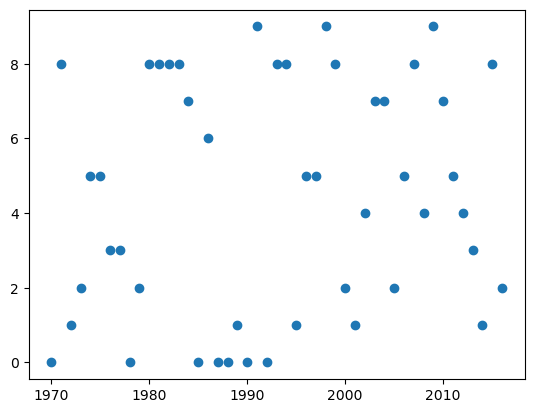

In [23]:
plt.scatter(df2['year'],df2['rand'])
plt.show()

In [24]:
reg3 = linear_model.LinearRegression()
reg3.fit(df2[['year']],df2.rand)

LinearRegression()

In [25]:
reg2.predict([[2024]])

C:\Users\HEMANTH KUMAR K\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([44602.55439531])

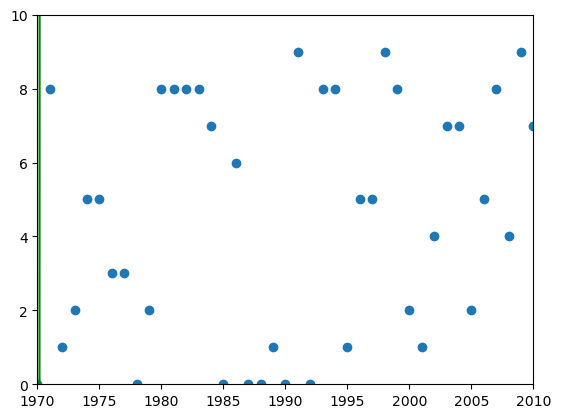

In [26]:
plt.scatter(df2.year,df2.rand)
plt.plot(df2[['year']],reg2.predict(df2[['year']]),color = 'green')
plt.xlim(1970,2010)
plt.ylim(0,10)
plt.show()

## ✅ Conclusion

In this project, we:

- Built a Simple Linear Regression model
- Understood the regression equation
- Visualized the best-fit line
- Evaluated model performance

This notebook strengthens the understanding of regression fundamentals before moving to more complex models like Multiple Linear Regression.